In [3]:
!pip install minatar

In [4]:
import minatar
env = minatar.Environment("breakout")
print("State shape:", env.state_shape())
print("Num actions:", env.num_actions())

State shape: [10, 10, 4]
Num actions: 6


# 01 — Behavior Cloning (Imitation Learning)
В этом ноутбуке мы:

- загружаем экспертный датасет из DQN,
- обучаем имитационную сеть (Behavior Cloning),
- оцениваем качество BC vs Random vs Expert,
- сохраняем графики и GIF для отчёта.

Используем MiniAtari Breakout, эксперт взят из `00_setup_and_dqn.ipynb`.


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader


# путь проекта (такой же как в первом ноутбуке)
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/rl-final-project"

print("PROJECT DIR:", DRIVE_PROJECT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT DIR: /content/drive/MyDrive/rl-final-project


In [6]:
import minatar

env = minatar.Environment("breakout")
print("State shape:", env.state_shape())
print("Num actions:", env.num_actions())


State shape: [10, 10, 4]
Num actions: 6


In [7]:
def preprocess_state(st):
    arr = np.array(st, dtype=np.float32)
    if arr.ndim == 3:
        arr = np.sum(arr, axis=2)
    # нормализация
    mn, mx = arr.min(), arr.max()
    rng = mx - mn if mx > mn else 1.0
    arr = (arr - mn) / rng
    return arr.flatten()

def state_to_numpy(st):
    arr = np.array(st, dtype=np.float32)
    return arr


In [8]:
expert_path = os.path.join(DRIVE_PROJECT_DIR, "dqn", "expert_dataset.pkl")

with open(expert_path, "rb") as f:
    data = pickle.load(f)

print("Total transitions:", len(data))

states = np.stack([d[0] for d in data])   # state_flat
actions = np.array([d[1] for d in data], dtype=np.int64)

print("states:", states.shape)
print("actions:", actions.shape)

train_s, val_s, train_a, val_a = train_test_split(
    states, actions, test_size=0.1, random_state=42
)

print("Train:", train_s.shape, "Val:", val_s.shape)


Total transitions: 30000
states: (30000, 100)
actions: (30000,)
Train: (27000, 100) Val: (3000, 100)


In [9]:
class ExpertDataset(Dataset):
    def __init__(self, states, actions):
        self.states = torch.tensor(states, dtype=torch.float32)
        self.actions = torch.tensor(actions, dtype=torch.long)
    def __len__(self):
        return len(self.states)
    def __getitem__(self, idx):
        return self.states[idx], self.actions[idx]

batch_size = 128

train_loader = DataLoader(ExpertDataset(train_s, train_a), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(ExpertDataset(val_s, val_a), batch_size=batch_size)


In [10]:
input_dim = train_s.shape[1]    # должно быть 100
n_actions = env.num_actions()

class BC_MLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, n_actions):
        super().__init__()
        layers = []
        last = input_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        layers.append(nn.Linear(last, n_actions))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bc_model = BC_MLP(input_dim, [256,128], n_actions).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bc_model.parameters(), lr=1e-3)

bc_model


BC_MLP(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=6, bias=True)
  )
)

In [11]:
num_epochs = 15
train_losses = []
val_losses = []
val_accs = []

for epoch in range(1, num_epochs+1):
    bc_model.train()
    run_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = bc_model(xb)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * xb.size(0)
    train_loss = run_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # validation
    bc_model.eval()
    correct, total, vl = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = bc_model(xb)
            loss = criterion(logits, yb)
            vl += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    val_loss = vl / len(val_loader.dataset)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch}/{num_epochs} | train={train_loss:.4f} | val={val_loss:.4f} | acc={val_acc:.4f}")

# save model
bc_path = os.path.join(DRIVE_PROJECT_DIR, "imitation", "bc_model.pth")
torch.save(bc_model.state_dict(), bc_path)
print("Saved BC model ->", bc_path)


Epoch 1/15 | train=1.7596 | val=1.7468 | acc=0.2287
Epoch 2/15 | train=1.7319 | val=1.7242 | acc=0.2520
Epoch 3/15 | train=1.7129 | val=1.7043 | acc=0.2533
Epoch 4/15 | train=1.7010 | val=1.6940 | acc=0.2610
Epoch 5/15 | train=1.6919 | val=1.6939 | acc=0.2673
Epoch 6/15 | train=1.6869 | val=1.6878 | acc=0.2647
Epoch 7/15 | train=1.6814 | val=1.6884 | acc=0.2730
Epoch 8/15 | train=1.6789 | val=1.6808 | acc=0.2763
Epoch 9/15 | train=1.6763 | val=1.6850 | acc=0.2667
Epoch 10/15 | train=1.6756 | val=1.6812 | acc=0.2663
Epoch 11/15 | train=1.6745 | val=1.6779 | acc=0.2757
Epoch 12/15 | train=1.6726 | val=1.6797 | acc=0.2717
Epoch 13/15 | train=1.6714 | val=1.6812 | acc=0.2743
Epoch 14/15 | train=1.6706 | val=1.6837 | acc=0.2707
Epoch 15/15 | train=1.6700 | val=1.6783 | acc=0.2737
Saved BC model -> /content/drive/MyDrive/rl-final-project/imitation/bc_model.pth


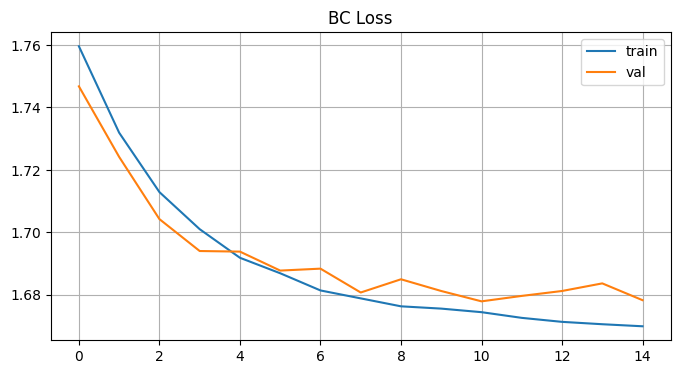

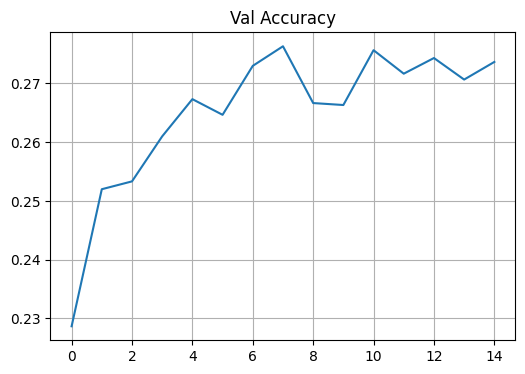

In [12]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.legend(); plt.grid(); plt.title("BC Loss")
plt.savefig(os.path.join(DRIVE_PROJECT_DIR, "plots", "bc_loss.png"))
plt.show()

plt.figure(figsize=(6,4))
plt.plot(val_accs)
plt.grid(); plt.title("Val Accuracy")
plt.savefig(os.path.join(DRIVE_PROJECT_DIR, "plots", "bc_acc.png"))
plt.show()


In [13]:
def run_policy(env, policy_fn, n_steps=400):
    env.reset()
    state = preprocess_state(env.state())
    total = 0.0
    for _ in range(n_steps):
        action = policy_fn(state)
        reward, done = env.act(action)
        total += reward
        state = preprocess_state(env.state())
    return total

def random_policy(s):
    return np.random.randint(n_actions)

def bc_policy(s):
    with torch.no_grad():
        x = torch.tensor(s, dtype=torch.float32).unsqueeze(0).to(device)
        return int(bc_model(x).argmax(dim=1).item())

# load DQN expert
from torch import load as torchload

expert_path = os.path.join(DRIVE_PROJECT_DIR, "dqn", "best_model.pth")
from math import isnan

expert_model = None
if os.path.exists(expert_path):
    from torch import load
    from torch.nn import Linear
    expert_model = BC_MLP(input_dim, [256,128], n_actions).to(device)
    expert_model.load_state_dict(torch.load(expert_path, map_location=device))
    expert_model.eval()
    def expert_policy(s):
        with torch.no_grad():
            x = torch.tensor(s, dtype=torch.float32).unsqueeze(0).to(device)
            return int(expert_model(x).argmax(dim=1).item())
    print("Expert loaded!")
else:
    print("Expert not found — skipping expert comparison")


Expert loaded!


In [14]:
runs = 10
steps = 400

results = {
    "random": [],
    "bc": [],
    "expert": []
}

for i in range(runs):
    r_rand = run_policy(env, random_policy, steps)
    r_bc = run_policy(env, bc_policy, steps)

    results["random"].append(r_rand)
    results["bc"].append(r_bc)

    if expert_model is not None:
        r_exp = run_policy(env, expert_policy, steps)
        results["expert"].append(r_exp)

    print(f"Run {i+1}/{runs}: random={r_rand:.1f}  bc={r_bc:.1f}" +
          (f"  expert={r_exp:.1f}" if expert_model is not None else ""))

print("\nMEAN STD:")
for k, v in results.items():
    if len(v) > 0:
        print(f"{k}: {np.mean(v):.2f} ± {np.std(v):.2f}")

# save results
with open(os.path.join(DRIVE_PROJECT_DIR, "imitation", "bc_eval.pkl"), "wb") as f:
    pickle.dump(results, f)


Run 1/10: random=0.0  bc=4.0  expert=2.0
Run 2/10: random=1.0  bc=2.0  expert=3.0
Run 3/10: random=0.0  bc=1.0  expert=3.0
Run 4/10: random=0.0  bc=1.0  expert=3.0
Run 5/10: random=0.0  bc=4.0  expert=3.0
Run 6/10: random=1.0  bc=1.0  expert=3.0
Run 7/10: random=0.0  bc=3.0  expert=1.0
Run 8/10: random=0.0  bc=1.0  expert=0.0
Run 9/10: random=0.0  bc=1.0  expert=1.0
Run 10/10: random=3.0  bc=1.0  expert=3.0

MEAN STD:
random: 0.50 ± 0.92
bc: 1.90 ± 1.22
expert: 2.20 ± 1.08


In [16]:
import imageio
from PIL import Image

def save_bc_gif(env, policy_fn, n_steps=400, scale=20):
    frames = []
    env.reset()
    state = preprocess_state(env.state())
    for _ in range(n_steps):
        action = policy_fn(state)
        reward, done = env.act(action)
        st = state_to_numpy(env.state())

        img = st.sum(axis=2) if st.ndim == 3 else st
        img_norm = ((img - img.min()) / (img.max() - img.min() + 1e-8) * 255).astype(np.uint8)

        up = Image.fromarray(img_norm).resize((img_norm.shape[0]*scale, img_norm.shape[1]*scale), Image.NEAREST)
        frames.append(np.array(up))

        state = preprocess_state(env.state())

    path = os.path.join(DRIVE_PROJECT_DIR, "visuals", "bc_rollout", "bc.gif")
    imageio.mimsave(path, frames, fps=10)
    print("Saved BC GIF:", path)
    return path

os.makedirs(os.path.join(DRIVE_PROJECT_DIR, "visuals", "bc_rollout"), exist_ok=True)
print("Папка создана:", os.path.join(DRIVE_PROJECT_DIR, "visuals", "bc_rollout"))

save_bc_gif(env, bc_policy)


Папка создана: /content/drive/MyDrive/rl-final-project/visuals/bc_rollout
Saved BC GIF: /content/drive/MyDrive/rl-final-project/visuals/bc_rollout/bc.gif


'/content/drive/MyDrive/rl-final-project/visuals/bc_rollout/bc.gif'

In [17]:
import os

rollout_dir = "/content/drive/MyDrive/rl-final-project/visuals/expert_rollout"
if os.path.exists(rollout_dir):
    print("Directory exists. Content:", os.listdir(rollout_dir))
else:
    print("Directory does NOT exist:", rollout_dir)


Directory exists. Content: []
